# Image Processing and Colony Isolation: Network Plot and Group Comparison

In this notebook, we aim to investigate bacterial colony growth by processing microscopy images and quantifying colony sizes. Specifically, we focus on comparing **auxotroph**-**auxotroph** versus **auxotroph**-**prototroph** donor interactions and their effects on growth. Our primary goal is to determine if bacterial colonies display different growth patterns when the donor is an auxotroph compared to a prototroph. This analysis is performed by segmenting colonies in images, transforming them into binary formats, and quantifying growth based on pixel intensity. 

After identifying successful growth in different donor-recipient pairs, we construct network plots to visualize the interactions. The final step involves comparing the number of successful interactions in auxotroph-auxotroph pairs versus auxotroph-prototroph pairs using statistical methods such as the **Mann-Whitney U test** and visualizing the results through violin plots.

### **Libraries Used**

To achieve this, we leverage several powerful libraries for image processing, visualization, and statistical analysis:

- **NumPy (`numpy`)**: A core library for numerical operations in Python, used here to handle arrays and perform mathematical operations, particularly for image data and statistical computations.

- **PIL (`Image`)**: A popular Python Imaging Library for opening, manipulating, and saving images in various formats. We use it to load and process the microscopy images.

- **Matplotlib (`matplotlib.pyplot`)**: A comprehensive library for creating static, animated, and interactive visualizations in Python. In this notebook, it's used for plotting violin plots, network visualizations, and creating custom visualizations for image processing results.

- **Matplotlib Widgets (`RectangleSelector`)**: This allows interactive selection of regions within plots, aiding in the visualization of segmented colonies from microscopy images.

- **Scikit-Image (`skimage.color`, `skimage.util`, `skimage.filters`)**:
  - `rgb2gray`: Converts color images to grayscale to simplify binary transformations and thresholding.
  - `img_as_ubyte`: Converts images to 8-bit unsigned byte format, making the data easier to handle for pixel intensity analysis.
  - `threshold_otsu`: Automatically determines an optimal threshold for binarizing grayscale images, a key step in quantifying the growth of colonies from image data.

By combining these libraries, we aim to conduct a robust and reproducible analysis of bacterial colony growth, quantify differences between interaction types, and provide insightful visualizations to support our conclusions.

In [600]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte
from skimage.filters import threshold_otsu

### Function Overview: `process_image_and_coordinates`

This function is designed to process microscopy images of bacterial colonies and quantify colony size by counting the number of white pixels in sub-images extracted from specified coordinates. It takes a grayscale image of bacterial colonies and a text file containing coordinates, binarizes each sub-image, and counts the number of white pixels, which is used as a proxy for colony size.

The process involves four main steps:
1. **Importing the image**: Convert the image to grayscale and transform it into a NumPy array.
2. **Importing coordinates**: Extract coordinates from a text file in Mathematica format, which will define the regions of interest (i.e., sub-images).
3. **Sub-image extraction**: From the original grayscale image, extract smaller sub-images using the provided coordinates.
4. **Image binarization**: Convert the grayscale sub-images into black-and-white images by applying a threshold. This simplifies the image to just two values: black (0) and white (1).
5. **White pixel counting**: Count the number of white pixels in each binarized sub-image, which represents the growth or size of the bacterial colony in that region.

### 1. Image Import Function

In [ ]:
def import_image(image_path):
    """Imports a .jpg image as a grayscale NumPy array."""
    img = Image.open(image_path).convert('L')  # Convert the image to grayscale
    return np.array(img)

This function uses the **Python Imaging Library (PIL)** to load an image from a specified path and convert it to grayscale (which removes color information, leaving a single channel). It then converts the image into a NumPy array, allowing easy numerical manipulation of the pixel data in the following steps.

### 2. Coordinates Import Function

In [ ]:
def import_coordinates(file_path):
    """Imports coordinates from a .txt file and converts them from Mathematica's curly braces to Python's square brackets."""
    with open(file_path, 'r') as file:
        # Read the content of the file
        content = file.read().strip()
    
    # Split the content to isolate the part after the equal sign
    _, coordinates_str = content.split('=')
    
    # Remove any whitespace from the extracted coordinates
    coordinates_str = coordinates_str.strip()
    
    # Replace curly braces with square brackets
    coordinates_str = coordinates_str.replace('{', '[').replace('}', ']')
    
    # Convert the string to a Python list
    coordinates_list = eval(coordinates_str)
    
    return coordinates_list

This function reads a `.txt` file containing coordinates formatted in **Mathematica's curly braces** style, replaces them with Python-compatible square brackets, and converts the string into a Python list of coordinates using the `eval()` function. These coordinates define rectangular areas within the image from which sub-images are extracted.

### 3. Sub-image Extraction Function

In [ ]:
def extract_subimage(image, coordinates):
    """Extracts a sub-image from the original image based on the provided coordinates."""
    x_range, y_range = coordinates
    return image[x_range[0]:x_range[1], y_range[0]:y_range[1]]

Once the coordinates have been imported, this function extracts sub-images from the main image. The image is represented as a NumPy array, and the coordinates are used to slice the array, isolating the relevant portions of the image.

### 4. Image Binarization Function

In [ ]:
def binarize_image(image, threshold=0.5):
    """
    Binarizes a grayscale image using a given threshold.
    
    Parameters:
    - image: The input grayscale image as a NumPy array.
    - threshold: The threshold value for binarization. Should be between 0 and 1.
    
    Returns:
    - A binarized image as a NumPy array where pixel values are either 0 or 1.
    """
    # Normalize the image if not already in the range [0, 1]
    if image.max() > 1:
        image = image / 255.0
    
    # Apply the threshold to binarize the image
    binarized_image = (image > threshold).astype(np.uint8)
    
    return binarized_image

This function converts a grayscale image into a black-and-white (binary) image. The `threshold` parameter determines which pixels are considered "white" (values above the threshold) and which are "black" (values below the threshold). This step is crucial because bacterial colonies are often represented by white regions in the image, and we want to isolate these regions.

- The image is normalized to a scale of 0 to 1 (if it hasn't been normalized already) to ensure consistent binarization.
- After applying the threshold, pixels with values greater than the threshold are set to 1 (white), and those below are set to 0 (black).

### 5. White Pixel Counting Function

In [ ]:
def count_white_pixels(binarized_image):
    """Counts the number of white pixels (value of 1) in a binarized image."""
    return np.sum(binarized_image == 1)

Once the image is binarized, this function counts the number of white pixels (`1`s). The count of white pixels can serve as a proxy for the colony size in that region of the image.

### 6. Main Function: Processing Image and Coordinates


In [ ]:
def process_image_and_coordinates(image_path, coordinates_file_path, threshold=0.5):
    """
    Imports an image and coordinates, extracts sub-images, binarizes them, and counts white pixels.
    
    Parameters:
    - image_path: Path to the .jpg image.
    - coordinates_file_path: Path to the .txt file containing coordinates.
    - threshold: The threshold value for binarization. Default is 0.5.
    
    Returns:
    - A list of integers representing the number of white pixels in each binarized sub-image.
    """
    # Step 1: Import the image
    img = import_image(image_path)
    
    # Step 2: Import the coordinates
    coordinates = import_coordinates(coordinates_file_path)
    
    # Step 3: Process each set of coordinates to extract, binarize, and count white pixels
    white_pixel_counts = []
    
    for coord in coordinates:
        sub_image = extract_subimage(img, coord)  # Extract the sub-image
        binarized_sub_image = binarize_image(sub_image, threshold)  # Binarize the sub-image
        white_pixel_count = count_white_pixels(binarized_sub_image)  # Count the white pixels
        white_pixel_counts.append(white_pixel_count)  # Append the count to the list
    
    return white_pixel_counts

This is the main function that integrates all the helper functions. It processes the entire image based on the provided coordinates and threshold, and returns a list of integers where each integer represents the number of white pixels in the corresponding sub-image. Each step is performed in a loop for each set of coordinates:
- Extract the sub-image.
- Binarize the sub-image.
- Count the white pixels.

### Negative control

In [3]:
#negative control
image_path = "negativeve control.jpg"
coordinates_file_path = "outputs/vectrl.txt"
white_pixel_counts = process_image_and_coordinates(image_path, coordinates_file_path)
print(white_pixel_counts)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 25, 152, 0, 0, 0, 0, 0, 0, 0, 0, 3296, 2777, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 46, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Positive control

In [4]:
#positive control
image_path = "_positive_control.jpg"
coordinates_file_path = "outputs/coordinates_colony_isolation_ctrl.txt"
white_pixel_counts = process_image_and_coordinates(image_path, coordinates_file_path)
print(white_pixel_counts)

[0, 0, 0, 0, 0, 0, 1296, 0, 2637, 2313, 3475, 2380, 1980, 1817, 1581, 2054, 6127, 5372, 5143, 5470, 5929, 6839, 0, 0, 1410, 1683, 1068, 1320, 5, 5, 2176, 2582, 4328, 3023, 2323, 3280, 1108, 1696, 0, 0, 675, 433, 1880, 1864, 2320, 2585, 0, 438, 2041, 1789, 1690, 1845, 1214, 1292, 1282, 1351, 2212, 1755, 1557, 1482, 1718, 1636, 2016, 2908, 1779, 1756, 1715, 1556, 1644, 1615, 1716, 2152, 2310, 1960, 1840, 1762, 1456, 1504, 2047, 2384, 2081, 1601, 1385, 1361, 1401, 1362, 1527, 2156, 4086, 3763, 1817, 1514, 1641, 1931, 2301, 3035]


### Automatic Version

In [602]:
image_path = "1_5d_b.jpg"
coordinates_file_path = "outputs/1_5d_b.txt"
white_pixel_counts = process_image_and_coordinates(image_path, coordinates_file_path)
print(white_pixel_counts)

[31, 25, 0, 0, 15, 37, 12, 1, 34, 15, 14, 25, 2, 0, 0, 6, 4036, 3788, 3459, 3210, 2999, 3085, 17, 8, 9, 7, 4, 588, 1909, 0, 3227, 2447, 0, 0, 36, 0, 568, 639, 0, 2, 421, 0, 3, 35, 33, 8, 24, 26, 2936, 2456, 2229, 18, 1209, 1184, 1619, 1256, 15, 0, 0, 0, 0, 0, 0, 2, 6, 1, 0, 18, 0, 0, 0, 0, 23, 0, 2, 0, 0, 0, 19, 0, 44, 0, 0, 0, 4, 0, 0, 6, 74, 4, 0, 0, 0, 0, 0, 0]


### Function Overview: `find_files`

This function, `find_files`, is designed to search a specified directory and return a list of all files that match a particular file type, such as `.jpg`, `.png`, or any other file extension. It systematically checks each file in the directory, determines if it matches the desired file type, and, if so, adds it to the list with its complete path.

### Purpose of the Function

The primary purpose of this function is to automate the task of collecting all files of a certain type (e.g., images, text files, etc.) from a directory. This can be particularly useful in situations where you need to batch-process a set of files or images, such as the microscopy images in a bacterial colony analysis pipeline.

### Function Breakdown

In [ ]:
def find_files(directory, filetype):
    files = []
    for filename in os.listdir(directory):
        if filename.endswith(filetype):
            files.append(os.path.join(directory, filename))
    return files

- **Parameters:**
  - `directory`: This parameter specifies the path to the folder in which the function will look for files. It can be an absolute or relative path.
  - `filetype`: This is the file extension you want to search for (e.g., `.jpg`, `.png`, `.txt`). The function will only return files that end with this specified extension.

- **Steps:**
  1. **Initialize an Empty List**: The function begins by creating an empty list, `files`, which will eventually store all the matching files.
  
  2. **Iterate Through Files in the Directory**: 
     - The function uses `os.listdir(directory)` to get a list of all files (and subdirectories) in the specified directory.
     - It loops through each item (filename) in the directory.
  
  3. **Check the File Extension**: 
     - For each file, the function uses the `endswith()` method to check if the filename ends with the desired `filetype` (such as `.jpg`).
     - If the file matches the extension, it proceeds to the next step.
  
  4. **Add the File to the List**:
     - The function uses `os.path.join(directory, filename)` to create the complete file path and appends it to the `files` list.
     - `os.path.join()` ensures the correct concatenation of the directory path and filename, creating a platform-independent path (whether you're using Windows, macOS, or Linux).
  
  5. **Return the List of Files**: 
     - Once the loop completes, the function returns the list `files`, which contains the full paths of all files that match the specified `filetype`.

### Example Use Case

In [ ]:
# Example usage to find all .jpg files in a directory
directory = "/path/to/images"
filetype = ".jpg"
jpg_files = find_files(directory, filetype)
print(jpg_files)


- **Explanation**:
  - This example will search the `/path/to/images` directory for all `.jpg` files.
  - The function will return a list of the full paths to these files, which can then be used for further processing, such as loading them into a bacterial colony analysis pipeline.

### Notes:
- **File Types**: You can use this function to search for any file type by adjusting the `filetype` argument (e.g., `.png`, `.txt`).
- **Subdirectories**: This version of the function does not search inside subdirectories. If recursive searching is needed, the function would need to be modified to handle subdirectory traversal (e.g., using `os.walk()`).

In [604]:
fileImagePath = find_files("", ".jpg")

In [605]:
fileImagePath

['data/colony_images/colonypics/8.1_5d_b.jpg',
 'data/colony_images/colonypics/16_5d_b.jpg',
 'data/colony_images/colonypics/30.1_5d_b.jpg',
 'data/colony_images/colonypics/28_5d_b.jpg',
 'data/colony_images/colonypics/29_5d_b.jpg',
 'data/colony_images/colonypics/16bio_5_b.jpg',
 'data/colony_images/colonypics/4_5d_b.jpg',
 'data/colony_images/colonypics/5_5d_b.jpg',
 'data/colony_images/colonypics/5.1_5d_b.jpg',
 'data/colony_images/colonypics/43.1_5d_b.jpg',
 'data/colony_images/colonypics/22_9d_b.jpg',
 'data/colony_images/colonypics/16.1_5d_b.jpg',
 'data/colony_images/colonypics/23_5d_b.jpg',
 'data/colony_images/colonypics/4.1bio_5d_b.jpg',
 'data/colony_images/colonypics/39_bio_5d_b.jpg',
 'data/colony_images/colonypics/38.1_9d_b.jpg',
 'data/colony_images/colonypics/16.1bio_5_b.jpg',
 'data/colony_images/colonypics/18bio_5d_b.jpg',
 'data/colony_images/colonypics/3.1bio_5d_b.jpg',
 'data/colony_images/colonypics/7.1bio_5d_b.jpg',
 'data/colony_images/colonypics/13.1_5d_b.jpg',

In [606]:
fileCoordPath = find_files("", "outputs/.txt")

In [607]:
fileCoordPath

['data/colony_images/individual image coordinates/38_5d_b.txt',
 'data/colony_images/individual image coordinates/39_5d_b.txt',
 'data/colony_images/individual image coordinates/32_bio_5d_b.txt',
 'data/colony_images/individual image coordinates/18_5d_b3.txt',
 'data/colony_images/individual image coordinates/35_bio_5d_b.txt',
 'data/colony_images/individual image coordinates/32.1_5d_b.txt',
 'data/colony_images/individual image coordinates/6bio_5d_b.txt',
 'data/colony_images/individual image coordinates/18_5d_b2.txt',
 'data/colony_images/individual image coordinates/13.1_bio_5d_b.txt',
 'data/colony_images/individual image coordinates/19.1_5d_b.txt',
 'data/colony_images/individual image coordinates/37.1_bio_b.txt',
 'data/colony_images/individual image coordinates/37_bio_b.txt',
 'data/colony_images/individual image coordinates/27_bio_5d_b.txt',
 'data/colony_images/individual image coordinates/32_5d_b.txt',
 'data/colony_images/individual image coordinates/33_5d_b.txt',
 'data/col

### Function Overview: `extract_sort_key`

The function `extract_sort_key` is designed to extract numerical values (both integers and floating-point numbers) from strings, while keeping non-numeric parts of the string intact. The extracted numbers and non-numeric parts are returned in a format that allows for custom sorting. This is particularly useful when filenames contain both text and numbers (e.g., `image1.5.txt`, `image2.txt`), and you want to sort them in a way that respects both their numeric and textual parts.

### Purpose of the Function

The goal of this function is to enable sorting a list of filenames or file paths in a "natural order." Natural sorting ensures that numbers are sorted by their numeric value rather than as a sequence of characters. For example, `image2.jpg` should come before `image10.jpg`, even though alphabetically, `"10"` comes before `"2"`.

### Function Breakdown

In [1]:
def extract_sort_key(file_path):
    # Use regular expressions to find all numbers (including decimals) and return a tuple of parts
    return [float(part) if part.replace('.', '', 1).isdigit() else part for part in re.split(r'(\d+\.\d+|\d+)', file_path)]

- **Parameters:**
  - `file_path`: The string (or file path) from which numeric and non-numeric parts are extracted for sorting purposes.

- **Steps:**
  1. **Regular Expression Split**:
     - The function uses the `re.split()` function with the regular expression `r'(\d+\.\d+|\d+)'` to split the `file_path` string.
     - The regular expression looks for:
       - `\d+`: Matches integers (one or more digits).
       - `\d+\.\d+`: Matches floating-point numbers (one or more digits, a decimal point, and one or more digits after the decimal).
     - This splits the string into parts: numbers and non-numeric substrings.
  
  2. **Numeric Conversion**:
     - The function then iterates through the parts returned from the split.
     - If a part represents a number (either an integer or float), it is converted to a `float`.
     - If a part is not numeric (e.g., text), it remains unchanged.
     - The result is a list of parts where numbers are represented as floats and other parts remain as strings.

  3. **Return List**:
     - The function returns a list of parts (mix of floats and strings) that can be used as the sorting key.

### Sorting the List

In [ ]:
# Sort the list using the custom sorting key
sorted_file_Coord_paths = sorted(fileCoordPath, key=extract_sort_key)

- **`sorted()` with a Custom Key**:
  - The `sorted()` function is used to sort `fileCoordPath`, a list of file paths, based on the custom sorting key generated by `extract_sort_key`.
  - The key ensures that numbers within the filenames are sorted numerically, while non-numeric parts are sorted alphabetically.

### Example Use Case

In [ ]:
fileCoordPath = ["image2.jpg", "image10.jpg", "image1.jpg", "image1.5.jpg"]
sorted_file_Coord_paths = sorted(fileCoordPath, key=extract_sort_key)

for path in sorted_file_Coord_paths:
    print(path)

**Output:**

In [ ]:
image1.jpg
image1.5.jpg
image2.jpg
image10.jpg

- **Explanation**:
  - In this example, the files are sorted in "natural order" because the numeric parts (`1`, `1.5`, `2`, `10`) are sorted according to their numeric values, not lexicographically (alphabetically).

### Why is this Useful?

1. **Natural Sorting**: If your filenames contain numbers, this approach ensures that they are sorted logically (by number size) rather than by string comparison, where `"10"` would appear before `"2"`.
   
2. **Mixed Content**: The function works for filenames with both numbers and text, making it flexible and useful in various scenarios.

3. **Handles Decimals**: By handling both integers and floating-point numbers, the function is robust and can manage filenames like `file1.5.txt` or `file10.3.txt`.

### Conclusion

The `extract_sort_key` function is a utility that simplifies the sorting of filenames or file paths with embedded numbers, ensuring they are sorted naturally based on the numeric and text components. By combining regular expressions and custom sorting logic, the function is highly versatile for file management tasks.

In [612]:
image_path = '1.1bio_5d_b.jpg'
coordinates_file_path = 'outputs/1.1bio_5d_b.txt'
white_pixel_counts = process_image_and_coordinates(image_path, coordinates_file_path)
print(white_pixel_counts)

[13, 4, 17, 23, 4, 0, 27, 54, 2, 853, 5189, 0, 0, 212, 33, 646, 6328, 6600, 5189, 4802, 4371, 4783, 1, 76, 5, 8, 9, 0, 2516, 0, 1546, 1718, 3, 4, 0, 64, 539, 756, 71, 12, 261, 0, 2, 0, 3, 79, 8, 7, 2655, 2463, 2473, 2, 1487, 1426, 1533, 1475, 2, 0, 0, 0, 42, 43, 17, 39, 8, 0, 0, 0, 0, 5, 0, 0, 0, 27, 0, 0, 2, 0, 0, 76, 51, 0, 0, 0, 96, 0, 0, 30, 0, 0, 0, 0, 0, 0, 0, 0]


### Purpose of the following Code: Ensuring Dataset Consistency Between Images and Coordinates

The goal of the provided code is to ensure that the dataset of images and the corresponding dataset of coordinates (stored in separate files) are properly aligned. Since images and their corresponding coordinate files are stored in different directories and have different file extensions (e.g., `.jpg` for images and `.txt` for coordinates), the code aims to extract and match the core file names, ensuring that the correct image has its corresponding coordinate file.

### Key Steps:

1. **Removing Directory Paths and File Extensions:**
   - Two separate functions are created to remove the directory path and file extension for the image dataset (`.jpg`) and the coordinates dataset (`.txt`). 
   - These functions take lists of file paths, extract the core part of the filename, and return a list of processed filenames without the full path and extensions.
   
2. **Matching Processed Lists:**
   - After extracting the core filenames, a comparison is made between the processed image dataset and the processed coordinates dataset to verify that they match.

### Function 1: `extract_substrings`

This function processes the list of image file paths (ending in `.jpg`) by removing the directory path and file extension.


In [ ]:
def extract_substrings(file_list):
    # Define the part to remove at the start and the end
    start_remove = ""
    end_remove = ".jpg"
    
    # Use list comprehension to process each file path
    result_list = [file_path.replace(start_remove, "").replace(end_remove, "") for file_path in file_list]
    
    return result_list

- **Parameters:**
  - `file_list`: A list of file paths (in this case, paths to `.jpg` image files).
  
- **Process:**
  - The function removes the specified directory path (`start_remove`) and the file extension (`end_remove`) from each image file path using Python's `replace()` method.
  - This is done through a list comprehension, making it a quick and efficient process.
  
- **Return Value:**
  - A list of filenames, with both the directory path and `.jpg` extension removed, leaving only the core file name.

### Function 2: `extract_substringsTxt`

This function performs a similar process but for the `.txt` files containing the coordinates.


In [ ]:
def extract_substringsTxt(file_list):
    # Define the part to remove at the start and the end
    start_remove = ""
    end_remove = "outputs/.txt"
    
    # Use list comprehension to process each file path
    result_list = [file_path.replace(start_remove, "").replace(end_remove, "") for file_path in file_list]
    
    return result_list

- **Parameters:**
  - `file_list`: A list of file paths (in this case, paths to `.txt` files containing coordinates).
  
- **Process:**
  - The function removes the specified directory path (`start_remove`) and the `.txt` file extension using Python's `replace()` method.
  
- **Return Value:**
  - A list of filenames with the directory path and `.txt` extension removed, leaving only the core file name.

### Verifying Dataset Consistency:

In [ ]:
namesSpeciesSorted = extract_substrings(sorted_file_Image_paths)
namesSpeciesSortedFromTXT = extract_substringsTxt(sorted_file_Coord_paths)

# Test if both lists are the same
namesSpeciesSorted == namesSpeciesSortedFromTXT

- **Steps:**
  - First, the `extract_substrings` function is applied to the sorted list of image file paths (`sorted_file_Image_paths`) to extract the core filenames.
  - Then, the `extract_substringsTxt` function is applied to the sorted list of coordinate file paths (`sorted_file_Coord_paths`) to extract the core filenames from the `.txt` files.
  - Finally, the two resulting lists are compared using the equality operator `==` to verify that they are identical.
  
- **Expected Output:**
  - If the two lists are identical, the comparison will return `True`, meaning that for every image file, there is a corresponding coordinate file, and both datasets are perfectly aligned.


In [614]:
namesSpeciesSorted = extract_substrings(sorted_file_Image_paths)

In [617]:
namesSpeciesSortedFromTXT = extract_substringsTxt(sorted_file_Coord_paths)

In [619]:
namesSpeciesSorted==namesSpeciesSortedFromTXT

True

Now, we perform a loop to process image and coordinate files using the `process_image_and_coordinates` function, and it store the resulting data in a list of lists (`all_data`). 

### Code Breakdown:

#### Function: `collect_all_results`

In [ ]:
def collect_all_results(sorted_file_Image_paths, sorted_file_Coord_paths):
    all_results = []  # Initialize an empty list to store the results
    
    for kl in range(147):  # Loop through kl values from 0 to 147 (147 total entries)
        result = process_image_and_coordinates(sorted_file_Image_paths[kl], sorted_file_Coord_paths[kl])
        all_results.append(result)  # Append the result of each process to the list
    
    return all_results  # Return the complete list of lists

1. **Purpose:**
   - This function is designed to loop through the `sorted_file_Image_paths` and `sorted_file_Coord_paths` (which are assumed to be matched datasets).
   - For each index (`kl`), it processes the corresponding image and its related coordinates using the `process_image_and_coordinates` function.

2. **How It Works:**
   - The function initializes an empty list (`all_results`) to store the results.
   - It then loops through each image and its corresponding coordinate file using the index `kl`. In each iteration, it processes the image and coordinates and appends the result (likely a count of white pixels, based on your earlier `process_image_and_coordinates` function) to the `all_results` list.
   - Finally, it returns the complete list of results.

#### Execution of the Function:

In [ ]:
# Assuming sorted_file_Image_paths and sorted_file_Coord_paths are already defined
all_data = collect_all_results(sorted_file_Image_paths, sorted_file_Coord_paths)

# Now all_data contains the list of lists

1. **Step-by-Step:**
   - The `collect_all_results` function is called with the `sorted_file_Image_paths` and `sorted_file_Coord_paths` as input.
   - The function processes each image and its corresponding coordinate file (for 147 entries) and appends the results to `all_data`.
   - The final output (`all_data`) will be a list of lists, where each sublist contains the number of white pixels in the sub-images processed from the image/coordinate pairs.

2. **Output:**
   - `all_data` will be a list of lists. Each sublist will correspond to the results (e.g., white pixel counts) for one image and its respective coordinate file.
   - For example, if each image had several regions of interest, the corresponding sublist might contain counts like `[100, 150, 120]` (depending on the results of each processed region in the image).


### Removing Auxotrophs:

In this section of the project, the goal is to filter out cases where bacterial colonies were observed in the positive control. These cases indicate that the bacteria behaved as prototrophs (and not auxotrophs, which are unable to grow without certain nutrients). To proceed with the analysis, we need to remove these specific cases from further evaluation.

#### 1. **Removing positions from a list of lists**
The first part of the code removes certain elements from each sublist within a list of lists (`liOfLi`) based on the provided positions in `delList`. This is done using the `remove_positions()` function.


In [ ]:
def remove_positions(liOfLi, delList):
    """
    Removes elements from each sublist in a list of lists based on specific positions in delList.

    Parameters:
    - liOfLi: The list of lists containing elements.
    - delList: A list of positions (indices) of the elements that need to be removed.

    Returns:
    - A modified version of liOfLi where the elements at the specified positions are removed from each sublist.
    """
    
    # Create a new list to store the modified sublists
    modified_liOfLi = []
    
    # Iterate through each sublist in liOfLi
    for sublist in liOfLi:
        # Use list comprehension to keep elements that are not in the positions listed in delList
        modified_sublist = [elem for idx, elem in enumerate(sublist) if idx not in delList]
        # Append the modified sublist to the new list
        modified_liOfLi.append(modified_sublist)
    
    return modified_liOfLi

# Example usage:
liOfLi = [['a1', 'b1', 'c1', 'd1', 'e1', 'f1', 'g1', 'h1', 'z1'],
          ['a2', 'b2', 'c2', 'd2', 'e2', 'f2', 'g2', 'h2', 'z2'],
          ['ak', 'bk', 'ck', 'dk', 'ek', 'fk', 'gk', 'hk', 'zk']]

delList = [0, 1, 6, 7]

# Apply the function
modified_liOfLi = remove_positions(liOfLi, delList)
print(modified_liOfLi)

- **Purpose:** The function `remove_positions()` takes in a list of lists (`liOfLi`) and a list of positions (`delList`) that need to be removed. The function iterates over each sublist and removes the elements at the specified positions.
  
- **Process:** 
  - A list comprehension is used to filter out the elements at the indices found in `delList`.
  - Each modified sublist is appended to a new list (`modified_liOfLi`).
  
- **Result:** You get a new list where the specified elements are removed from each sublist.

#### 2. **Applying the function to `all_data`**
The function is then applied to the `all_data` variable, which is assumed to contain the data you processed earlier.

In [ ]:
# Removing the specified positions from the all_data list
all_dataDelCor = remove_positions(all_data, coordinatesToRemove)

- **Purpose:** The `remove_positions()` function is now used to clean `all_data` by removing the positions that correspond to prototroph behavior in the positive control.

#### 3. **Removing positions from a single list**
In some cases, you might only have a single list (not a list of lists). For this, you use the `remove_positions_from_list()` function.


In [ ]:
def remove_positions_from_list(single_list, delList):
    """
    Removes elements from a single list based on specific positions in delList.

    Parameters:
    - single_list: The list containing elements.
    - delList: A list of positions (indices) of the elements that need to be removed.

    Returns:
    - A modified version of single_list where the elements at the specified positions are removed.
    """
    
    # Use list comprehension to keep elements that are not in the positions listed in delList
    modified_list = [elem for idx, elem in enumerate(single_list) if idx not in delList]
    return modified_list

# Example usage:
single_list = ['a1', 'b1', 'c1', 'd1', 'e1', 'f1', 'g1', 'h1', 'z1']
delList = [0, 1, 6, 7]

# Apply the function
modified_list = remove_positions_from_list(single_list, delList)
print(modified_list)

- **Purpose:** This function does the same thing as `remove_positions()` but works on a single list instead of a list of lists.

- **Example:** After removing the specified positions from `negativeControl0`, you store the result in `negativeControl`.

In [ ]:
negativeControl = remove_positions_from_list(negativeControl0, coordinatesToRemove)


### 1. **Function: `extract_first_numbers()`**


In [ ]:
def extract_first_numbers(input_list):
    extracted_numbers = []
    
    for item in input_list:
        match = re.match(r'^\d+', item)  # Match one or more digits at the start
        if match:
            extracted_numbers.append(match.group())  # Append the matched number to the result list
        else:
            extracted_numbers.append("")  # Append empty string if no match found
    
    return extracted_numbers

#### **Explanation:**
- **Purpose:** This function extracts the first number (integer) from each string in the input list.
- **How:** It uses regular expressions to find and match the first integer part of each string. If the string contains a number at the start, it extracts it; otherwise, it appends an empty string.
- **Example:**
  - Input: `["1abc", "20xyz", "abc"]`
  - Output: `["1", "20", ""]`

### 2. **Function: `combine_lists()`**

In [ ]:
def combine_lists(lisOflis, auxoX, donorX):
    result = []

    for col_idx, auxo in enumerate(auxoX):
        for row_idx, donor in enumerate(donorX):
            result.append([auxo, donor, lisOflis[row_idx][col_idx]])
    
    return result

#### **Explanation:**
- **Purpose:** Combines three lists (a list of lists `lisOflis`, `auxoX`, and `donorX`) into a list of sublists, where each sublist has three elements: `auxoX`, `donorX`, and the corresponding element from `lisOflis`.
- **How:** The function iterates over each combination of elements from `auxoX` (representing the columns) and `donorX` (representing the rows) and collects them together with their corresponding values from `lisOflis`.
- **Example:**
  - Input: `lisOflis = [[3, 6], [1, 8]]`, `auxoX = ['a1', 'a2']`, `donorX = ['d1', 'd2']`
  - Output: `[['a1', 'd1', 3], ['a1', 'd2', 1], ['a2', 'd1', 6], ['a2', 'd2', 8]]`

### 3. **Function: `remove_duplicates()`**

In [ ]:
def remove_duplicates(input_list):
    reduced_list = [item[:2] for item in input_list]
    unique_list = list(map(list, set(map(tuple, reduced_list))))
    unique_list.sort()
    
    return unique_list

#### **Explanation:**
- **Purpose:** Removes duplicates from a list of lists, where only the first two elements of each sublist are considered for duplicate removal.
- **How:** The function uses a set of tuples to ensure uniqueness, then converts the set back into a list of lists and sorts the result.
- **Example:**
  - Input: `[['1', '2', 0], ['1', '2', 1], ['2', '3', 0]]`
  - Output: `[['1', '2'], ['2', '3']]`

### 4. **Function: `clean_and_sort_list()`**

In [ ]:
def clean_and_sort_list(input_list):
    cleaned_list = [item for item in input_list if item[0] != item[1]]
    cleaned_list.sort(key=lambda x: (int(x[0]), int(x[1])))
    
    return cleaned_list

#### **Explanation:**
- **Purpose:** Cleans a list by removing sublists where the first and second elements are the same and then sorts the remaining sublists.
- **How:** The function uses list comprehension to filter out sublists where the two elements are equal, and then it sorts the list based on the integer values of the elements.
- **Example:**
  - Input: `[['1', '1'], ['1', '2'], ['3', '3']]`
  - Output: `[['1', '2']]`

### 5. **Function: `partition_list()`**

In [ ]:
def partition_list(input_list):
    list_one = []
    list_two = []
    
    for item in input_list:
        second_element = int(item[1])
        if second_element <= 24:
            list_one.append(item)
        else:
            list_two.append(item)
    
    return list_one, list_two

#### **Explanation:**
- **Purpose:** Partitions a list into two based on whether the second element of each sublist is less than or equal to 24, or greater than 24.
- **How:** The function loops through the input list, checks the second element, and adds the sublist to `list_one` if it’s less than or equal to 24, otherwise to `list_two`.
- **Example:**
  - Input: `[['1', '15'], ['1', '25']]`
  - Output: `([['1', '15']], [['1', '25']])`

### 6. **Function: `filter_list_by_elements()`**

In [ ]:
def filter_list_by_elements(data, first_element, second_element):
    result = [item for item in data if item[0] == first_element and item[1] == second_element]
    return result

#### **Explanation:**
- **Purpose:** Filters a list of sublists based on matching the first and second elements.
- **How:** It loops through the input list and returns sublists that match the provided `first_element` and `second_element`.
- **Example:**
  - Input: `[['1', '15', 0], ['1', '25', 1]]`, `first_element = '1'`, `second_element = '15'`
  - Output: `[['1', '15', 0]]`

### 7. **Function: `process_list()`**

In [ ]:
def process_list(input_list):
    if not input_list:
        return []
    
    colum_list = [sublist[2] for sublist in input_list]
    count_greater_than_zero = sum(1 for x in colum_list if x > 0)
    result_value = 1 if count_greater_than_zero >= len(colum_list) / 2 else 0
    
    return [input_list[0][0], input_list[0][1], result_value]

#### **Explanation:**
- **Purpose:** Determines whether there is significant growth in the data by checking if at least half of the sublists have a positive value in the third position.
- **How:** The function extracts the third element of each sublist, checks how many of them are greater than zero, and returns `1` if at least half are positive; otherwise, it returns `0`.
- **Example:**
  - Input: `[['1', '15', 1], ['1', '15', 0], ['1', '15', 1]]`
  - Output: `['1', '15', 1]`


### 1. **Function: `process_all_combinations()`**

In [ ]:
def process_all_combinations(combinations_list, allCombThreeAuxDonGrowth):
    results = []
    for comb in combinations_list:
        # Extract the first and second elements of the sublist (comb)
        str1 = comb[0]
        str2 = comb[1]
        
        # Apply the process_list and filter_list_by_elements functions
        result = process_list(filter_list_by_elements(allCombThreeAuxDonGrowth, str1, str2))
        
        # Append the result to the results list
        results.append(result)
    
    return results

#### **Explanation:**
- **Purpose:** This function processes a list of combinations by applying two functions: `process_list()` and `filter_list_by_elements()`. It filters the data based on two elements (e.g., donor and recipient IDs) and computes whether there is growth based on the rules defined in `process_list()`.
- **How:** The function loops through each combination (e.g., ['1', '3']), applies the filtering function to match the combination, processes the results, and appends the outcome to the `results` list.
- **Example:**
  - Input: `combinations = [['1', '3'], ['1', '34'], ['4', '12']]`
  - Output: A list of processed results based on those combinations.

---

### 2. **Function: `get_unique_elements()`**

In [ ]:
def get_unique_elements(lst, column):
    """
    This function returns the unique elements from the first or second column 
    of a list of lists.
    """
    if column not in [0, 1]:
        raise ValueError("Column argument must be 0 (first column) or 1 (second column)")
    
    return list(set(sublist[column] for sublist in lst))

#### **Explanation:**
- **Purpose:** Extracts the unique elements from a specified column (either the first or second) of a list of lists.
- **How:** The function checks if the column number is valid (either `0` or `1`), then it uses a set to extract unique values from the selected column.
- **Example:**
  - Input: `[['1', '2', 0], ['2', '3', 0], ['1', '3', 1]]`
  - Output (first column): `['1', '2']`

---

### 3. **Example Usage:**

In [ ]:
# Get unique elements from the first column
unique_first_column = sorted(get_unique_elements(data, 0))
print("Unique elements in first column:", unique_first_column)

# Get unique elements from the second column
unique_second_column = sorted(get_unique_elements(data, 1))
print("Unique elements in second column:", unique_second_column)

#### **Explanation:**
- **Purpose:** This shows how to use the `get_unique_elements()` function to extract unique values from the first and second columns of a dataset.
- **How:** The example extracts and sorts the unique elements from the first and second columns, then prints the results.

---

### 4. **Function: `sort_as_integers()`**

In [ ]:
def sort_as_integers(lst):
    """
    This function sorts a list of strings representing numbers
    based on their integer values.
    """
    return sorted(lst, key=lambda x: int(x))

#### **Explanation:**
- **Purpose:** Sorts a list of strings that represent numbers based on their integer values.
- **How:** The function converts each string in the list to an integer using a lambda function and then sorts the list.
- **Example:**
  - Input: `['10', '2', '30', '5']`
  - Output: `['2', '5', '10', '30']`

---

### 5. **Auxotrophs and Prototrophs Analysis:**

In [ ]:
unique_recipients_AA = get_unique_elements(AAgrowth, 0)
unique_donors_AA = get_unique_elements(AAgrowth, 1)
unique_recipients_AP = get_unique_elements(APgrowth, 0)
unique_donors_AP = get_unique_elements(APgrowth, 1)

#### **Explanation:**
- **Purpose:** After processing auxotroph-auxotroph (AA) and auxotroph-prototroph (AP) interaction networks, this section of the code extracts the unique donors and recipients from both networks.
- **How:** The `get_unique_elements()` function is used to extract and sort the unique recipient and donor IDs for each interaction type (AA and AP networks).

In this project, we are visualizing interactions between bacterial colonies using Circos plots. Below is an explanation and breakdown of the two provided pieces of code for generating the **Auxotroph-Auxotroph** and **Prototroph-Auxotroph** interaction networks.

### **Auxotroph-Auxotroph Network Visualization**

#### 1. **Sectors Definition:**
   - The `sectors` dictionary defines 21 sectors, each representing a bacterial species or a group in the interaction network. Each sector has a value of `10`, which determines its relative size on the plot.
   - Colors are assigned to these sectors using `sector_colors`, with distinct colors for visualization.

#### 2. **Connections Definition:**
   - The `connections` dictionary defines which sectors are interacting with others, indicating a successful co-culture growth. Each sector (key in the dictionary) is connected to a list of other sectors (values).

#### 3. **Generating the Circos Plot:**
   - The Circos plot is initialized with custom spacing between sectors. The loop iterates over the sectors and adds a track for each, using the `track.axis()` function to fill them with the assigned colors.
   - For each connection, a non-overlapping link is generated between sectors, ensuring the visual clarity of the links. The color of the link is based on the sector (donor) initiating the connection.
   - After the links are plotted, the figure is saved as a high-quality PDF with a specific background color (`#DAC883`).

#### **Explanation of Specific Functions:**
   - `non_overlapping_link_positions()` ensures that links between sectors do not overlap by randomly generating start and end positions for each link.
   - `circos.link()` plots the actual connection between sectors based on the calculated positions, with a set line width and height ratio.

---




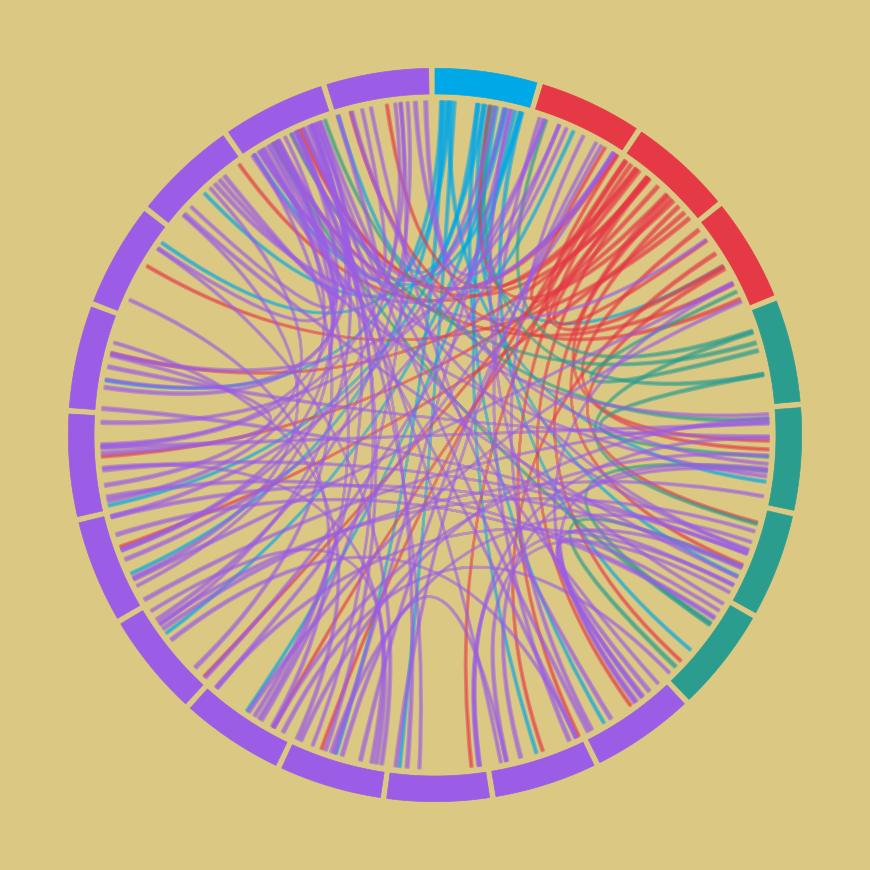

In [3]:
from pycirclize import Circos
import random

# Define 21 sectors, all of the same size
sectors = {f"Sector{i}": 10 for i in range(1, 22)}

# Assign colors to the sectors
sector_colors = ["#00A8E8"] + ["#E63946"] * 3 + ["#2A9D8F"] * 4 + ["#9B5DE5"] * 13

# Initialize the Circos plot with 21 sectors and spacing
circos = Circos(sectors, space=1)

# Increase the thickness of the sectors by adjusting the track's radius limits
for sector, color in zip(circos.sectors, sector_colors):
    track = sector.add_track((93, 100))  # Adjusted range to make sectors thicker
    track.axis(fc=color, ec=color)  # Fill sector with its respective color and no edge

# Define the matrix connections based on the 21 sectors
connections = {
    1: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 2, 6, 19, 7, 8, 20, 4, 21],
 2: [20],
 3: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 2, 6, 1, 19, 7, 8, 20, 4, 21],
 4: [10, 2, 6, 7, 20, 21],
 5: [2, 6, 1, 7, 20, 4],
 6: [20],
 8: [6, 7, 20],
 9: [2, 6, 1, 7, 8, 20, 4, 21],
 10: [2, 6, 7, 20],
 11: [2, 6, 7, 20],
 12: [10, 14, 16, 17, 18, 2, 6, 1, 7, 20],
 13: [18, 2, 6, 7, 8, 20, 4, 21],
 14: [10, 2, 6, 7, 20, 21],
 15: [2, 6, 1, 19, 7, 8, 20, 4, 21],
 16: [17, 2, 6, 19, 7, 8, 20, 21],
 17: [2, 6, 7, 20],
 19: [2, 6, 7, 20],
 20: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 2, 6, 1, 19, 7, 8, 4, 21],
 21: [2, 6, 7, 20]
}

# Function to generate smaller, non-overlapping link positions
def non_overlapping_link_positions(used_positions, sector_size, link_width=1.9):
    while True:
        start = random.uniform(0, sector_size - link_width)
        end = start + link_width
        if all(abs(start - u_start) > link_width and abs(end - u_end) > link_width for u_start, u_end in used_positions):
            used_positions.append((start, end))
            return start, end

# Create non-overlapping, smaller links between sectors with adjusted height and line width
for start_sector, connected_sectors in connections.items():
    for end_sector in connected_sectors:
        start_sector_name = f"Sector{start_sector}"
        end_sector_name = f"Sector{end_sector}"
        
        # Keep track of used positions to avoid overlap
        used_positions_start = []
        used_positions_end = []

        start_pos = non_overlapping_link_positions(used_positions_start, 10, link_width=0.3)
        end_pos = non_overlapping_link_positions(used_positions_end, 10, link_width=0.2)

        # Set link color based on one of the ""donorconnected"" sectors
        link_color = sector_colors[start_sector - 1]

        # Adjust the height ratio and line width (lw)
        circos.link((start_sector_name, *start_pos), (end_sector_name, *end_pos), color=link_color, lw=1.9, r1=91, r2=91, height_ratio=0.5)

# Plot the figure
fig = circos.plotfig()

# Set the figure size to be square
fig.set_size_inches(8, 8)

# Set the background color
fig.patch.set_facecolor('#DAC883')
ax = fig.axes[0]
ax.set_facecolor('#DAC883')

# Save the plot without transparency and with the specified background color
fig.savefig('outputs/circos_plot_21_sectors_background_Color4.pdf', facecolor='#DAC883', format='pdf', dpi=300, bbox_inches='tight', transparent=False)


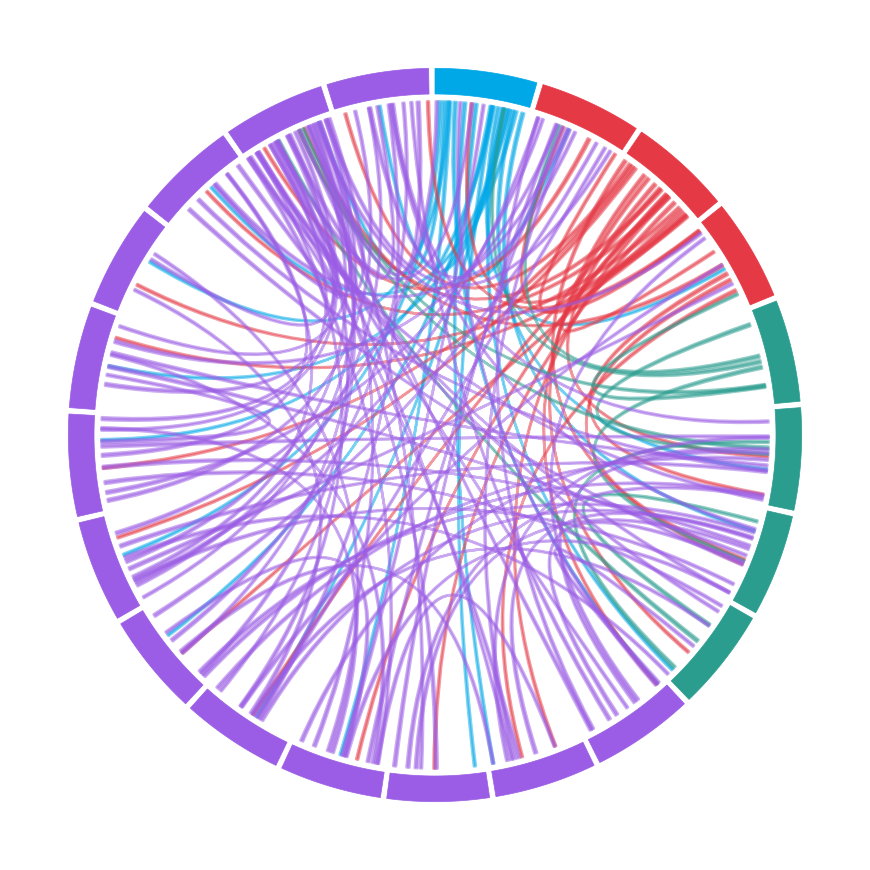

In [1102]:
from pycirclize import Circos
import random

# Define 21 sectors, all of the same size
sectors = {f"Sector{i}": 10 for i in range(1, 22)}

# Assign colors to the sectors
sector_colors = ["#00A8E8"] + ["#E63946"] * 3 + ["#2A9D8F"] * 4 + ["#9B5DE5"] * 13

# Initialize the Circos plot with 21 sectors and spacing
circos = Circos(sectors, space=1)

# Increase the thickness of the sectors by adjusting the track's radius limits
for sector, color in zip(circos.sectors, sector_colors):
    track = sector.add_track((93, 100))  # Adjusted range to make sectors thicker
    track.axis(fc=color, ec=color)  # Fill sector with its respective color and no edge

# Define the matrix connections based on the 21 sectors
connections = {
    1: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 2, 6, 19, 7, 8, 20, 4, 21],
 2: [20],
 3: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 2, 6, 1, 19, 7, 8, 20, 4, 21],
 4: [10, 2, 6, 7, 20, 21],
 5: [2, 6, 1, 7, 20, 4],
 6: [20],
 8: [6, 7, 20],
 9: [2, 6, 1, 7, 8, 20, 4, 21],
 10: [2, 6, 7, 20],
 11: [2, 6, 7, 20],
 12: [10, 14, 16, 17, 18, 2, 6, 1, 7, 20],
 13: [18, 2, 6, 7, 8, 20, 4, 21],
 14: [10, 2, 6, 7, 20, 21],
 15: [2, 6, 1, 19, 7, 8, 20, 4, 21],
 16: [17, 2, 6, 19, 7, 8, 20, 21],
 17: [2, 6, 7, 20],
 19: [2, 6, 7, 20],
 20: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 2, 6, 1, 19, 7, 8, 4, 21],
 21: [2, 6, 7, 20]
}

# Function to generate smaller, non-overlapping link positions
def non_overlapping_link_positions(used_positions, sector_size, link_width=1.9):
    while True:
        start = random.uniform(0, sector_size - link_width)
        end = start + link_width
        if all(abs(start - u_start) > link_width and abs(end - u_end) > link_width for u_start, u_end in used_positions):
            used_positions.append((start, end))
            return start, end

# Create non-overlapping, smaller links between sectors with adjusted height and line width
for start_sector, connected_sectors in connections.items():
    for end_sector in connected_sectors:
        start_sector_name = f"Sector{start_sector}"
        end_sector_name = f"Sector{end_sector}"
        
        # Keep track of used positions to avoid overlap
        used_positions_start = []
        used_positions_end = []

        start_pos = non_overlapping_link_positions(used_positions_start, 10, link_width=0.3)
        end_pos = non_overlapping_link_positions(used_positions_end, 10, link_width=0.2)

        # Set link color based on one of the "donor" sectors
        link_color = sector_colors[start_sector - 1]

        # Adjust the height ratio and line width (lw)
        circos.link((start_sector_name, *start_pos), (end_sector_name, *end_pos), color=link_color, lw=1.9, r1=91, r2=91, height_ratio=0.5)

# Plot the figure
fig = circos.plotfig()

# Save the plot as a high-quality, transparent PDF
fig.savefig('outputs/AuxoAuxoNetwork.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)



### **Prototroph-Auxotroph Network Visualization**

The second script follows a similar structure to the Auxotroph-Auxotroph network plot, but it is customized for a network involving **prototrophs** and **auxotrophs**.

#### **Key Differences:**
1. **Sectors and Colors:**
   - There are 40 sectors, reflecting a larger network of prototroph-auxotroph interactions.
   - A distinct color palette is used to differentiate between the different types of interactions.

2. **Custom Spacing:**
   - There is a custom spacing configuration (`custom_spaces`), which ensures specific space between some sectors to enhance the clarity of the visualization.

3. **Connections:**
   - Similar to the Auxotroph-Auxotroph plot, the connections between sectors are defined in the `connections` dictionary. Each key represents a prototroph or auxotroph that is linked to a set of other sectors.

---

### **Customizing the Plot:**
Both the Auxotroph-Auxotroph and Prototroph-Auxotroph networks use the same Circos plotting methodology but can be customized in the following ways:
- **Color Scheme:** Adjusting the `sector_colors` array can change the visual representation of the sectors, allowing us to distinguish between different groups of bacteria.
- **Background and Layout:** The background color is set to `#DAC883` for the Auxotroph-Auxotroph plot. This color can be adjusted or set to transparent, depending on the desired aesthetics.
- **Link Color:** The color of the links is determined by the starting sector (the donor), but this can be customized to represent other metrics such as interaction strength or type.

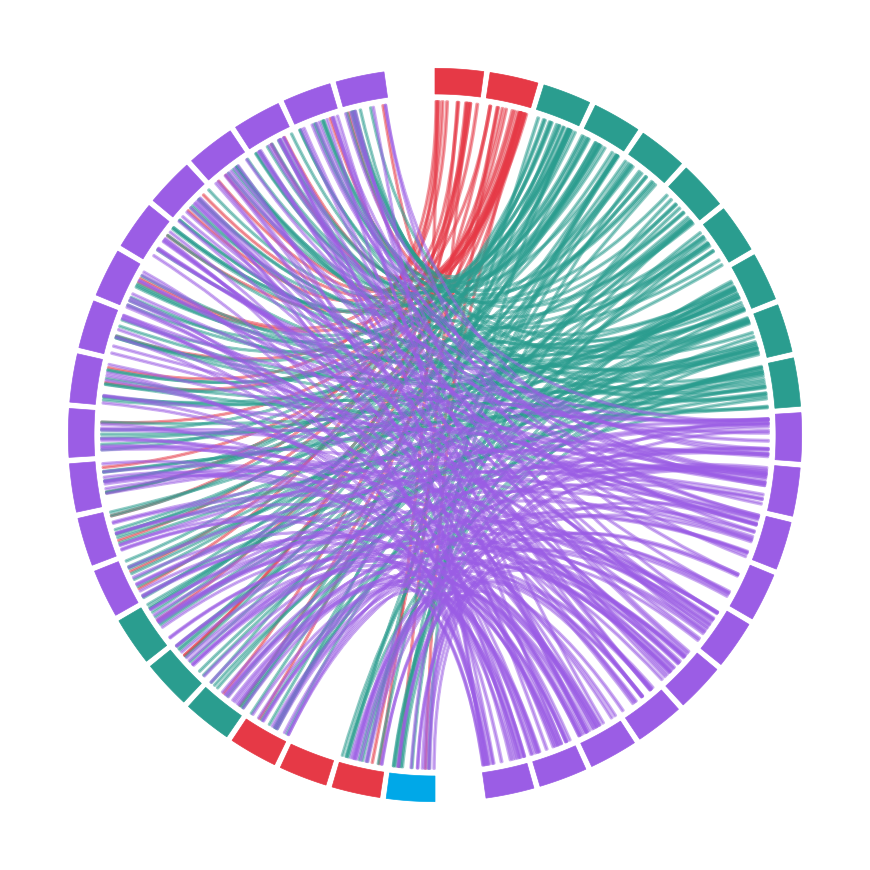

In [1103]:
from pycirclize import Circos
import random

# Define 21 sectors, all of the same size
sectors = {f"Sector{i}": 10 for i in range(1, 41)}

# Assign colors to the sectors
sector_colors = ["#E63946"] * 2 + ["#2A9D8F"] * 8 + ["#9B5DE5"] * 10 +  ["#00A8E8"] + ["#E63946"] * 3 + ["#2A9D8F"] * 3 + ["#9B5DE5"] * 13

# Define custom spacing between sectors (adding space between the last sector and the first one)
custom_spaces = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8]  # Now the length is 40

# Initialize the Circos plot with custom spacing
circos = Circos(sectors, space=custom_spaces)

# Increase the thickness of the sectors by adjusting the track's radius limits
for sector, color in zip(circos.sectors, sector_colors):
    track = sector.add_track((93, 100))  # Adjusted range to make sectors thicker
    track.axis(fc=color, ec=color)  # Fill sector with its respective color and no edge

# Define the matrix connections based on the 21 sectors
connections = {
    1: [28, 29, 30, 32, 34, 36, 37, 22, 25, 21, 38, 26, 40], 
    2: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    3: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    4: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    5: [28, 29, 30, 32, 22, 25, 21, 38, 27, 39, 24, 40], 
    6: [28, 32, 34, 36, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    7: [28, 29, 31, 32, 34, 36, 37, 22, 21, 38, 26, 24], 
    8: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    9: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    10: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    11: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    12: [28, 29, 30, 31, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    13: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    14: [22, 25, 21, 38, 27, 39, 24], 
    15: [29, 30, 31, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    16: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    17: [32, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24], 
    18: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40], 
    19: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24], 
    20: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 22, 25, 21, 38, 26, 27, 39, 24, 40]
}

# Function to generate smaller, non-overlapping link positions
def non_overlapping_link_positions(used_positions, sector_size, link_width=1.9):
    while True:
        start = random.uniform(0, sector_size - link_width)
        end = start + link_width
        if all(abs(start - u_start) > link_width and abs(end - u_end) > link_width for u_start, u_end in used_positions):
            used_positions.append((start, end))
            return start, end

# Create non-overlapping, smaller links between sectors with adjusted height and line width
for start_sector, connected_sectors in connections.items():
    for end_sector in connected_sectors:
        start_sector_name = f"Sector{start_sector}"
        end_sector_name = f"Sector{end_sector}"
        
        # Keep track of used positions to avoid overlap
        used_positions_start = []
        used_positions_end = []

        start_pos = non_overlapping_link_positions(used_positions_start, 10, link_width=0.3)
        end_pos = non_overlapping_link_positions(used_positions_end, 10, link_width=0.2)

        # Set link color based on one of the donor sectors
        link_color = sector_colors[start_sector - 1]

        # Adjust the height ratio and line width (lw)
        circos.link((start_sector_name, *start_pos), (end_sector_name, *end_pos), color=link_color, lw=1.9, r1=91, r2=91, height_ratio=0.5)

# Plot the figure
fig = circos.plotfig()

# Save the plot as a high-quality, transparent PDF
fig.savefig('outputs/circos_plot_21_sectors_transparentAP.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)

In this part of the analysis, we compared the number of interactions resulting in growth between **Auxotroph-Auxotroph** and **Auxotroph-Prototroph** pairs using a violin plot and a **Mann-Whitney U test** to determine statistical significance.

### ** Plot :**

The violin plot provides a visual representation of the distribution of growth percentages in cases where the donor was an auxotroph vs. when the donors were prototrophs. 

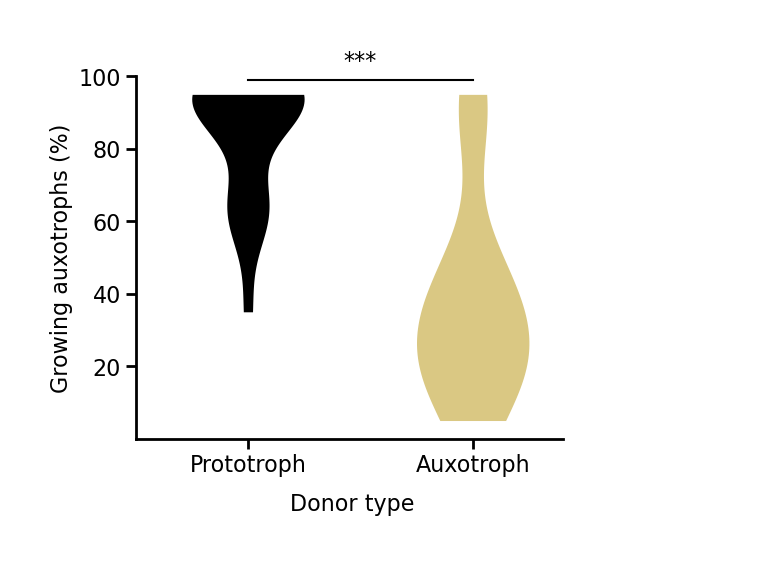

In [1139]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Prototrophs and Auxotrophs in percentages
prototrophs = 100 * np.array([13/20, 19/20, 19/20, 19/20, 12/20, 13/20, 12/20, 19/20, 19/20, 19/20, 19/20, 18/20, 19/20, 7/20, 17/20, 19/20, 13/20, 19/20, 18/20, 19/20])
auxotrophs = 100 * np.array([18/20, 1/20, 19/20, 6/20, 6/20, 1/20, 3/20, 8/20, 4/20, 4/20, 10/20, 8/20, 6/20, 9/20, 8/20, 4/20, 4/20, 18/20, 4/20])

# Combine the data into a single dataset
data = [prototrophs, auxotrophs]
labels = ['Prototroph', 'Auxotroph']

# Create the violin plot
fig, ax = plt.subplots(figsize=(7, 5))

# Adjust the distance between the violins by controlling the positions
positions = [1.0, 1.5]  # Move Auxotrophs closer to Prototrophs
parts = ax.violinplot(data, positions=positions, widths=0.25, showmeans=False, showmedians=False, showextrema=False)  # Width control with `widths`

# Customizing colors for each violin
violin_colors = ['black', '#DAC883']

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')  # Set the edge color to black for both violins
    pc.set_alpha(1)

# Set the x-axis labels and title
font2 = {'family': 'DejaVu Sans', 'color': 'black', 'size': 16}
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontdict=font2)
ax.set_ylabel('Growing auxotrophs (%)', fontdict=font2)

# Set custom ticks on y-axis at 20, 40, 80, 100
ax.set_yticks([20, 40, 60, 80, 100])
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

# Add a second x-axis label for "Donor type" and move it to the left
ax.set_xlabel('Donor type', fontsize=16, labelpad=25)
ax.xaxis.set_label_coords(0.37, -0.15)  # Moving "Donor type" to the left

# Adjust spacing between Prototrophs and the y-axis
ax.set_xlim(0.75, 2.05)  # Adjusted to keep the violins within a good range

# Set axis thickness and tick properties
tick_thickness = 2
ax.tick_params(axis='both', which='major', width=tick_thickness, direction='out', length=7)

# Set axis thickness and control how much of the x-axis line is visible
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_bounds(0.75, 1.7)  # Control the start and end of the x-axis line
ax.spines['left'].set_linewidth(2)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a line to indicate statistical significance
line_y = 99  # Y position of the line slightly below 100
ax.plot([1.0, 1.5], [line_y, line_y], lw=1.5, color='black')  # Line connecting the two violins
ax.text(1.25, line_y + 2, "***", ha='center', va='bottom', color='black', fontsize=16)  # Significance stars above the line

# Set y-axis limit to 100
ax.set_ylim(0, 100)  # The y-axis won't go beyond 100, but the line and stars will still be visible

# Tight layout to prevent clipping of ylabel
plt.tight_layout()

# Save the figure as a vector-quality PDF with a transparent background
plt.savefig('PlotCustomColors_Final.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)

# Display the plot
plt.show()


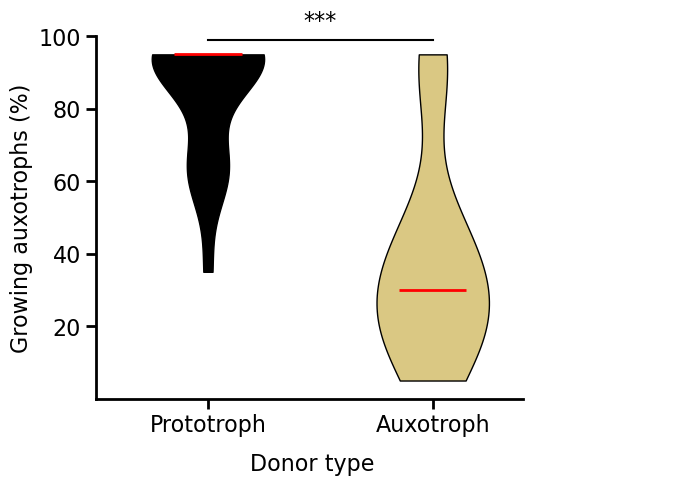

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# Parameters for Median Lines
# ===========================
median_line_width = 2          # Thickness of the median lines
median_line_length_fraction = 0.6  # Fraction of the violin width that the median line will cover
# ====================================

# Data for Prototrophs and Auxotrophs in percentages
prototrophs = 100 * np.array([
    13/20, 19/20, 19/20, 19/20, 12/20, 13/20, 12/20,
    19/20, 19/20, 19/20, 19/20, 18/20, 19/20,
    7/20, 17/20, 19/20, 13/20, 19/20, 18/20, 19/20
])
auxotrophs = 100 * np.array([
    18/20, 1/20, 19/20, 6/20, 6/20, 1/20, 3/20,
    8/20, 4/20, 4/20, 10/20, 8/20, 6/20,
    9/20, 8/20, 4/20, 4/20, 18/20, 4/20
])

# Combine the data into a single dataset
data = [prototrophs, auxotrophs]
labels = ['Prototroph', 'Auxotroph']

# Create the violin plot
fig, ax = plt.subplots(figsize=(7, 5))

# Adjust the distance between the violins by controlling the positions
positions = [1.0, 1.5]  # Move Auxotrophs closer to Prototrophs
violin_width = 0.25      # Width of the violins
parts = ax.violinplot(
    data,
    positions=positions,
    widths=violin_width,
    showmeans=False,
    showmedians=False,
    showextrema=False
)  # Width control with `widths`

# Customizing colors for each violin
violin_colors = ['black', '#DAC883']

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')  # Set the edge color to black for both violins
    pc.set_alpha(1)

# ===========================
# Compute and Plot Medians
# ===========================

# Calculate medians for each dataset
medians = [np.median(prototrophs), np.median(auxotrophs)]

# Iterate over each violin to plot the median lines
for i, (median, pos) in enumerate(zip(medians, positions)):
    # Determine the color based on violin index
    if i == 0:
        median_color = 'red'      # First violin (Prototroph) uses white color
    else:
        median_color = 'red'      # Second violin (Auxotroph) uses black color

    # Calculate the length of the median line
    # The median_line_length_fraction determines what fraction of the violin width the median line covers
    median_line_length = median_line_length_fraction * violin_width
    half_length = median_line_length / 2

    # Define the start and end points of the median line
    x_start = pos - half_length
    x_end = pos + half_length

    # Plot the median line
    ax.hlines(
        y=median,
        xmin=x_start,
        xmax=x_end,
        colors=median_color,
        linewidth=median_line_width
    )

# ====================================

# Set the x-axis labels and title
font2 = {'family': 'DejaVu Sans', 'color': 'black', 'size': 16}
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontdict=font2)
ax.set_ylabel('Growing auxotrophs (%)', fontdict=font2)

# Set custom ticks on y-axis at 20, 40, 60, 80, 100
ax.set_yticks([20, 40, 60, 80, 100])
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

# Add a second x-axis label for "Donor type" and move it to the left
ax.set_xlabel('Donor type', fontsize=16, labelpad=25)
ax.xaxis.set_label_coords(0.37, -0.15)  # Moving "Donor type" to the left

# Adjust spacing between Prototrophs and the y-axis
ax.set_xlim(0.75, 2.05)  # Adjusted to keep the violins within a good range

# Set axis thickness and tick properties
tick_thickness = 2
ax.tick_params(axis='both', which='major', width=tick_thickness, direction='out', length=7)

# Set axis thickness and control how much of the x-axis line is visible
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_bounds(0.75, 1.7)  # Control the start and end of the x-axis line
ax.spines['left'].set_linewidth(2)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a line to indicate statistical significance
line_y = 99  # Y position of the line slightly below 100
ax.plot([1.0, 1.5], [line_y, line_y], lw=1.5, color='black')  # Line connecting the two violins
ax.text(1.25, line_y + 2, "***", ha='center', va='bottom', color='black', fontsize=16)  # Significance stars above the line

# Set y-axis limit to 100
ax.set_ylim(0, 100)  # The y-axis won't go beyond 100, but the line and stars will still be visible

# Tight layout to prevent clipping of ylabel
plt.tight_layout()

# Save the figure as a vector-quality PDF with a transparent background
plt.savefig(
    'PlotCustomColors_Final.pdf',
    format='pdf',
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

# Display the plot
plt.show()


In [3]:
import numpy as np

# Data for Prototrophs and Auxotrophs in percentages
prototrophs = 100 * np.array([
    13/20, 19/20, 19/20, 19/20, 12/20, 13/20, 12/20,
    19/20, 19/20, 19/20, 19/20, 18/20, 19/20,
    7/20, 17/20, 19/20, 13/20, 19/20, 18/20, 19/20
])
auxotrophs = 100 * np.array([
    18/20, 1/20, 19/20, 6/20, 6/20, 1/20, 3/20,
    8/20, 4/20, 4/20, 10/20, 8/20, 6/20,
    9/20, 8/20, 4/20, 4/20, 18/20, 4/20
])

# Calculate medians for each dataset
median_prototrophs = np.median(prototrophs)
median_auxotrophs = np.median(auxotrophs)

# Display the median values
print(f"Median of Prototrophs: {median_prototrophs:.2f}%")
print(f"Median of Auxotrophs: {median_auxotrophs:.2f}%")


Median of Prototrophs: 95.00%
Median of Auxotrophs: 30.00%


### **Mann-Whitney U Test:**

We performed the **Mann-Whitney U test**, a non-parametric test used to compare differences between two independent groups. 

In [1111]:
import numpy as np
from scipy.stats import mannwhitneyu

# Data for Prototrophs and Auxotrophs in percentages
prototrophs = 100 * np.array([13/20, 19/20, 19/20, 19/20, 12/20, 13/20, 12/20, 19/20, 19/20, 19/20, 19/20, 18/20, 19/20, 7/20, 17/20, 19/20, 13/20, 19/20, 18/20, 19/20])
auxotrophs = 100 * np.array([18/20, 1/20, 19/20, 6/20, 6/20, 1/20, 3/20, 8/20, 4/20, 4/20, 10/20, 8/20, 6/20, 9/20, 8/20, 4/20, 4/20, 18/20, 4/20])

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(prototrophs, auxotrophs, alternative='two-sided')

# Get sample sizes
n_prototrophs = len(prototrophs)
n_auxotrophs = len(auxotrophs)

n_prototrophs, n_auxotrophs, stat, p_value

(20, 19, 344.5, 1.0767781570233803e-05)